# Campaign Performance Analytics Dashboard

**Marketing Analytics | Digital Analytics | Performance Marketing | Dashboarding**

This project analyzes campaign performance across paid, owned, and organic channels using realistic marketing data.

## Business Objective

Create a dashboard-ready analytics project to monitor spend, revenue, ROAS, CPA, conversion rate, and channel performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 1. Load Data


In [2]:
campaigns = pd.read_csv('../data/campaign_daily_performance.csv')
budget = pd.read_csv('../data/channel_weekly_budget.csv')

print('Campaign rows:', campaigns.shape)
print('Budget rows:', budget.shape)
campaigns.head()


Campaign rows: (2430, 20)
Budget rows: (104, 3)


,date,campaign_id,campaign_name,channel,campaign_type,region,device,impressions,clicks,spend_gbp,conversions,revenue_gbp,new_customers,assisted_conversions,ctr,cpc_gbp,conversion_rate,cpa_gbp,roas,aov_gbp
0,2025-01-01,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,UK,Desktop,12089,782,1144.54,58,3596.29,27,18,0.064687,1.463606,0.074169,19.733448,3.142127,62.005000
1,2025-01-02,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,UK,Mobile,9017,413,242.11,18,1170.39,8,7,0.045802,0.586223,0.043584,13.450556,4.834125,65.021667
2,2025-01-03,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,Germany,Mobile,10170,415,574.55,13,1205.99,7,5,0.040806,1.384458,0.031325,44.196154,2.099017,92.768462
3,2025-01-04,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,Germany,Mobile,10963,562,846.35,33,2664.03,23,9,0.051263,1.505961,0.058719,25.646970,3.147669,80.728182
4,2025-01-05,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,UK,Tablet,4853,209,216.08,20,1811.72,11,4,0.043066,1.033876,0.095694,10.804000,8.384487,90.586000


## 2. Dashboard KPI Cards


In [3]:
kpis = {
    'total_spend_gbp': campaigns['spend_gbp'].sum(),
    'total_revenue_gbp': campaigns['revenue_gbp'].sum(),
    'total_conversions': campaigns['conversions'].sum(),
    'total_clicks': campaigns['clicks'].sum(),
    'total_impressions': campaigns['impressions'].sum(),
    'overall_roas': campaigns['revenue_gbp'].sum() / campaigns['spend_gbp'].sum(),
    'overall_conversion_rate': campaigns['conversions'].sum() / campaigns['clicks'].sum(),
    'overall_ctr': campaigns['clicks'].sum() / campaigns['impressions'].sum(),
    'overall_cpa_gbp': campaigns['spend_gbp'].sum() / campaigns['conversions'].sum()
}

pd.DataFrame([kpis]).round(4)


,total_spend_gbp,total_revenue_gbp,total_conversions,total_clicks,total_impressions,overall_roas,overall_conversion_rate,overall_ctr,overall_cpa_gbp
0,441593.43,4237562.67,55532,914715,21449887,9.5961,0.0607,0.0426,7.9521


## 3. Channel Performance Summary


In [4]:
channel_summary = campaigns.groupby('channel').agg(
    impressions=('impressions','sum'),
    clicks=('clicks','sum'),
    spend_gbp=('spend_gbp','sum'),
    conversions=('conversions','sum'),
    revenue_gbp=('revenue_gbp','sum'),
    new_customers=('new_customers','sum'),
    assisted_conversions=('assisted_conversions','sum')
).reset_index()

channel_summary['ctr'] = channel_summary['clicks'] / channel_summary['impressions']
channel_summary['cpc_gbp'] = channel_summary['spend_gbp'] / channel_summary['clicks']
channel_summary['conversion_rate'] = channel_summary['conversions'] / channel_summary['clicks']
channel_summary['cpa_gbp'] = channel_summary['spend_gbp'] / channel_summary['conversions']
channel_summary['roas'] = channel_summary['revenue_gbp'] / channel_summary['spend_gbp'].replace(0, np.nan)
channel_summary = channel_summary.fillna(0).round(4).sort_values('revenue_gbp', ascending=False)
channel_summary


,channel,impressions,clicks,spend_gbp,conversions,revenue_gbp,new_customers,assisted_conversions,ctr,cpc_gbp,conversion_rate,cpa_gbp,roas
3,Email,3218610,308416,15439.17,26436,2042471.48,14344,7471,0.0958,0.0501,0.0857,0.5840,132.2915
4,Google Ads,3165470,141872,176525.35,8915,734724.79,4648,2635,0.0448,1.2443,0.0628,19.8009,4.1621
6,Organic Search,2433105,170095,0.00,8066,597340.39,4293,2352,0.0699,0.0000,0.0474,0.0000,0.0000
0,Affiliate,3219433,102815,96963.31,5202,361673.45,2688,1513,0.0319,0.9431,0.0506,18.6396,3.7300
1,Bing Ads,2293620,87712,79034.89,4538,358229.57,2363,1367,0.0382,0.9011,0.0517,17.4162,4.5325
5,Meta Ads,3202116,58051,47117.04,1579,99207.04,711,960,0.0181,0.8116,0.0272,29.8398,2.1055
7,TikTok Ads,2308701,31472,19758.79,578,31517.42,208,627,0.0136,0.6278,0.0184,34.1848,1.5951
2,Display,1608832,14282,6754.88,218,12398.53,54,394,0.0089,0.4730,0.0153,30.9857,1.8355


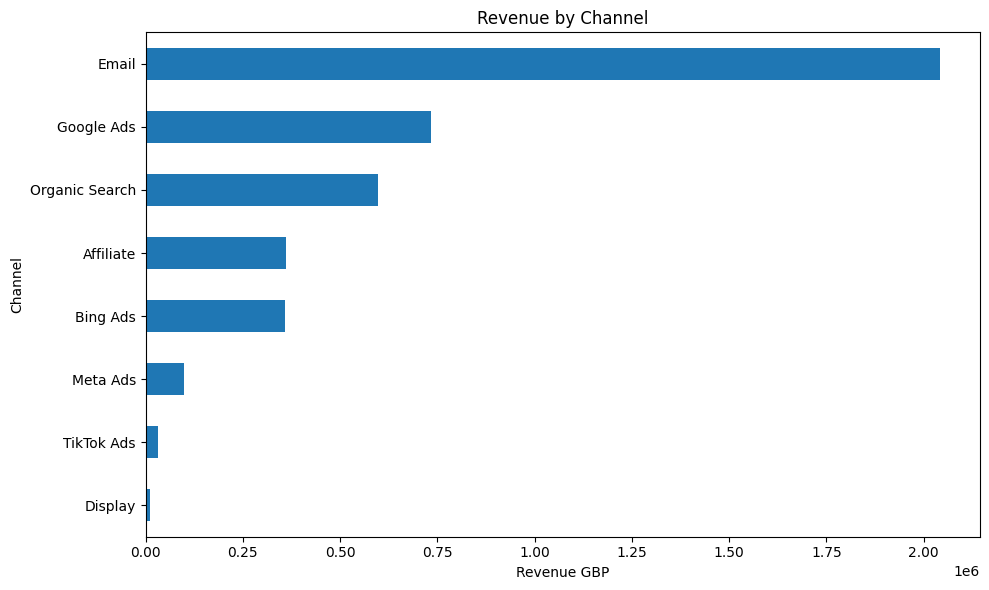

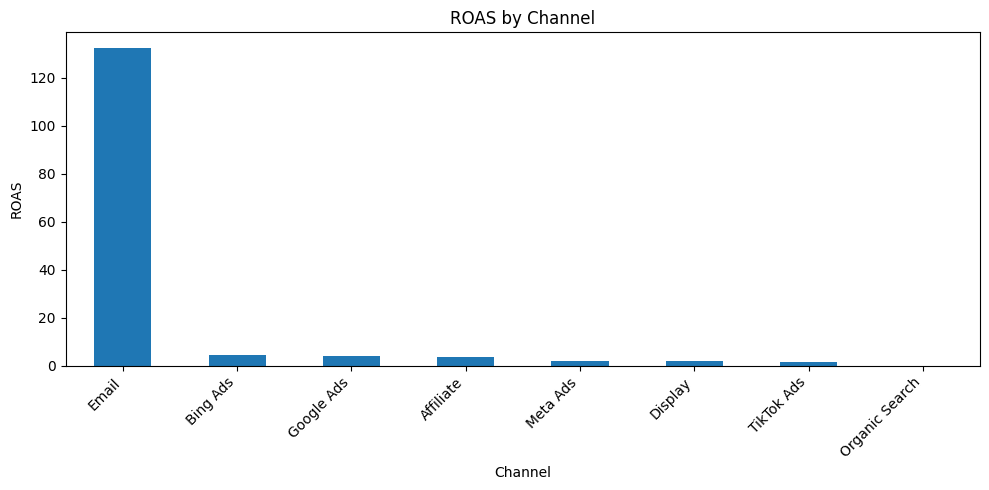

In [5]:
channel_summary.sort_values('revenue_gbp').plot(x='channel', y='revenue_gbp', kind='barh', figsize=(10,6), legend=False)
plt.title('Revenue by Channel')
plt.xlabel('Revenue GBP')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

channel_summary.sort_values('roas', ascending=False).plot(x='channel', y='roas', kind='bar', figsize=(10,5), legend=False)
plt.title('ROAS by Channel')
plt.xlabel('Channel')
plt.ylabel('ROAS')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Campaign Performance Summary


In [6]:
campaign_summary = campaigns.groupby(['campaign_id','campaign_name','channel','campaign_type']).agg(
    impressions=('impressions','sum'),
    clicks=('clicks','sum'),
    spend_gbp=('spend_gbp','sum'),
    conversions=('conversions','sum'),
    revenue_gbp=('revenue_gbp','sum'),
    new_customers=('new_customers','sum')
).reset_index()

campaign_summary['ctr'] = campaign_summary['clicks'] / campaign_summary['impressions']
campaign_summary['conversion_rate'] = campaign_summary['conversions'] / campaign_summary['clicks']
campaign_summary['cpa_gbp'] = campaign_summary['spend_gbp'] / campaign_summary['conversions']
campaign_summary['roas'] = campaign_summary['revenue_gbp'] / campaign_summary['spend_gbp'].replace(0, np.nan)
campaign_summary = campaign_summary.fillna(0).round(4).sort_values('roas', ascending=False)
campaign_summary.head(15)


,campaign_id,campaign_name,channel,campaign_type,impressions,clicks,spend_gbp,conversions,revenue_gbp,new_customers,ctr,conversion_rate,cpa_gbp,roas
9,CMP-1009,Email - Basket Recovery,Email,Basket Recovery,786760,74087,3859.98,8038,626702.60,4495,0.0942,0.1085,0.4802,162.3590
10,CMP-1010,Email - Loyalty,Email,Loyalty,787318,76388,3842.14,6198,484862.65,3352,0.0970,0.0811,0.6199,126.1960
11,CMP-1011,Email - Product Launch,Email,Product Launch,842189,80973,3958.74,6210,478029.17,3400,0.0961,0.0767,0.6375,120.7529
8,CMP-1008,Email - Newsletter,Email,Newsletter,802343,76968,3778.31,5990,452877.06,3097,0.0959,0.0778,0.6308,119.8623
25,CMP-1025,Bing Ads - Non-Brand Search,Bing Ads,Non-Brand Search,744575,28360,25864.62,1687,136399.18,861,0.0381,0.0595,15.3317,5.2736
24,CMP-1024,Bing Ads - Brand Search,Bing Ads,Brand Search,779621,30101,27039.78,1719,129153.76,898,0.0386,0.0571,15.7299,4.7764
0,CMP-1000,Google Ads - Brand Search,Google Ads,Brand Search,818282,37375,45131.42,2585,213993.39,1352,0.0457,0.0692,17.4590,4.7416
1,CMP-1001,Google Ads - Non-Brand Search,Google Ads,Non-Brand Search,780744,33347,42664.80,2378,191481.03,1230,0.0427,0.0713,17.9415,4.4880
15,CMP-1015,Affiliate - Comparison Site,Affiliate,Comparison Site,805216,25239,23687.85,1346,92820.49,701,0.0313,0.0533,17.5987,3.9185
12,CMP-1012,Affiliate - Cashback,Affiliate,Cashback,836597,27665,26154.41,1475,101833.60,773,0.0331,0.0533,17.7318,3.8936


## 5. Daily Trend Analysis


In [7]:
daily_summary = campaigns.groupby('date').agg(
    spend_gbp=('spend_gbp','sum'),
    conversions=('conversions','sum'),
    revenue_gbp=('revenue_gbp','sum'),
    clicks=('clicks','sum'),
    impressions=('impressions','sum')
).reset_index()

daily_summary['roas'] = daily_summary['revenue_gbp'] / daily_summary['spend_gbp'].replace(0, np.nan)
daily_summary['conversion_rate'] = daily_summary['conversions'] / daily_summary['clicks']
daily_summary = daily_summary.fillna(0).round(4)
daily_summary.head()


,date,spend_gbp,conversions,revenue_gbp,clicks,impressions,roas,conversion_rate
0,2025-01-01,4922.49,511,38335.52,7811,201362,7.7878,0.0654
1,2025-01-02,4701.57,589,46522.55,10115,233893,9.8951,0.0582
2,2025-01-03,4664.45,593,49266.38,9269,206695,10.5621,0.0640
3,2025-01-04,4890.96,621,50131.31,10441,239685,10.2498,0.0595
4,2025-01-05,4765.36,503,42600.20,8802,222499,8.9396,0.0571


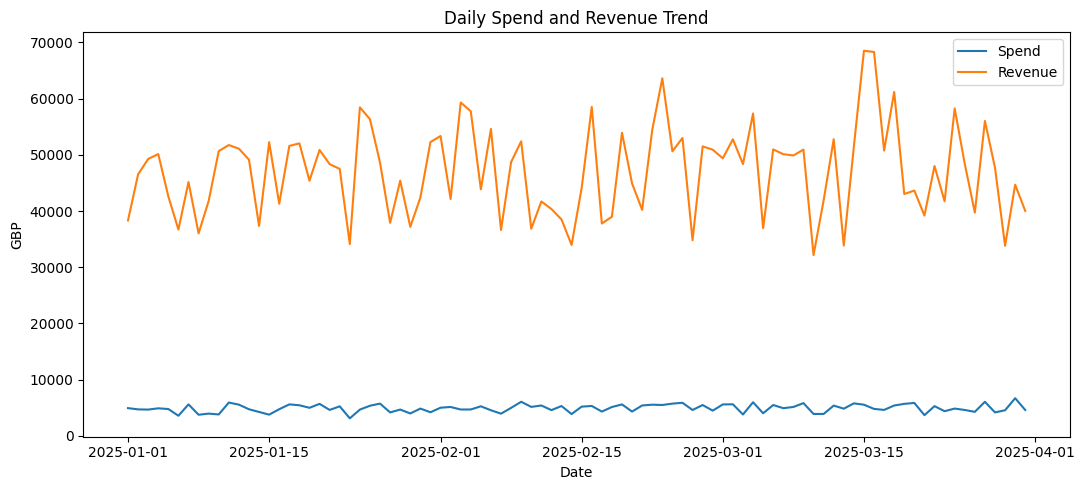

In [8]:
daily_summary['date'] = pd.to_datetime(daily_summary['date'])
plt.figure(figsize=(11,5))
plt.plot(daily_summary['date'], daily_summary['spend_gbp'], label='Spend')
plt.plot(daily_summary['date'], daily_summary['revenue_gbp'], label='Revenue')
plt.title('Daily Spend and Revenue Trend')
plt.xlabel('Date')
plt.ylabel('GBP')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Device and Channel Analysis


In [9]:
device_summary = campaigns.groupby(['device','channel']).agg(
    spend_gbp=('spend_gbp','sum'),
    conversions=('conversions','sum'),
    revenue_gbp=('revenue_gbp','sum'),
    clicks=('clicks','sum')
).reset_index()

device_summary['conversion_rate'] = device_summary['conversions'] / device_summary['clicks']
device_summary['roas'] = device_summary['revenue_gbp'] / device_summary['spend_gbp'].replace(0, np.nan)
device_summary = device_summary.fillna(0).round(4)
device_summary.head()


,device,channel,spend_gbp,conversions,revenue_gbp,clicks,conversion_rate,roas
0,Desktop,Affiliate,28193.05,1805,128602.35,30326,0.0595,4.5615
1,Desktop,Bing Ads,22449.98,1606,124846.03,24698,0.0650,5.5611
2,Desktop,Display,1765.09,51,2775.21,3421,0.0149,1.5723
3,Desktop,Email,4221.29,9306,711371.42,86778,0.1072,168.5199
4,Desktop,Google Ads,47456.15,2978,250173.98,38606,0.0771,5.2717


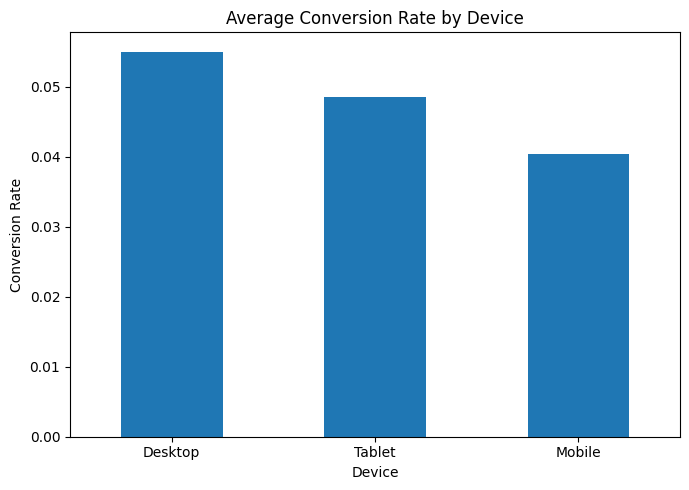

In [10]:
device_summary.groupby('device')['conversion_rate'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(7,5))
plt.title('Average Conversion Rate by Device')
plt.xlabel('Device')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Dashboard Design Blueprint

Recommended dashboard pages:

1. **Executive Overview**: Spend, Revenue, ROAS, CPA, CVR, CTR
2. **Channel Performance**: ROAS, CPA, revenue, spend by channel
3. **Campaign Deep Dive**: campaign-level table with filters
4. **Trend Analysis**: daily spend, revenue, conversions
5. **Device and Region Analysis**: performance by device and market

Recommended filters:

- Date
- Channel
- Campaign Type
- Region
- Device


## 8. Business Recommendations

### Budget Allocation
Shift incremental budget toward high-ROAS and low-CPA campaigns while protecting upper-funnel channels that drive assisted conversions.

### Email and Retention
Scale basket recovery and loyalty campaigns because owned channels often produce strong conversion efficiency.

### Paid Search
Separate brand and non-brand performance. Monitor non-brand CPA and shopping campaign ROAS.

### Paid Social and Display
Evaluate using assisted conversions and incrementality, not last-click ROAS only.

### Mobile Optimization
Improve mobile landing pages and checkout if conversion rate lags behind desktop.


In [11]:
channel_summary.to_csv('../reports/channel_performance_summary_from_notebook.csv', index=False)
campaign_summary.to_csv('../reports/campaign_performance_summary_from_notebook.csv', index=False)
daily_summary.to_csv('../reports/daily_trend_summary_from_notebook.csv', index=False)
device_summary.to_csv('../reports/device_channel_summary_from_notebook.csv', index=False)
print('Outputs saved successfully.')


Outputs saved successfully.
